<a href="https://colab.research.google.com/github/takumi0708/C_practices/blob/main/%E3%83%95%E3%83%BC%E3%83%AA%E3%82%A8%E8%A7%A3%E6%9E%90%E3%83%9F%E3%83%8B%E5%AE%9F%E9%A8%93.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

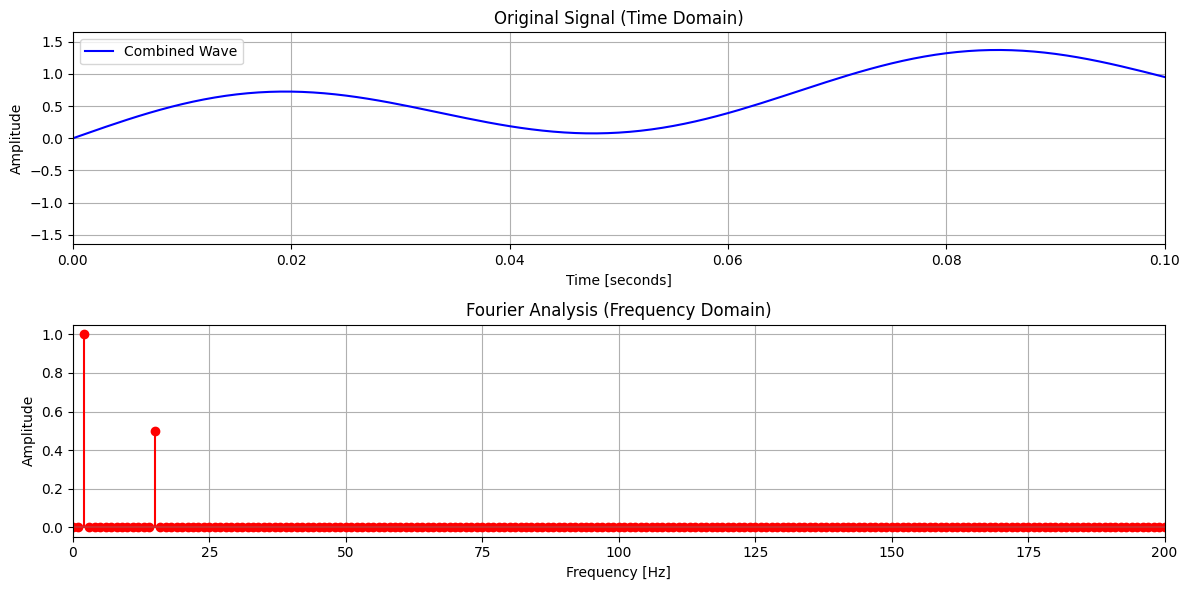

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. サンプリング設定
fs = 1000  # サンプリング周波数 (Hz) - 1秒間に何回データ点を取るか
t = np.arange(0, 1.0, 1 / fs)  # 時間軸 (0秒から1秒まで)

# 2. 三つの三角関数の組み合わせ（合成波の作成）
# 50Hz (振幅1.0) + 120Hz (振幅0.5)
f1, a1 = 2, 1.0
f2, a2 = 15, 0.5

wave1 = a1 * np.sin(2 * np.pi * f1 * t)
wave2 = a2 * np.sin(2 * np.pi * f2 * t)
signal = wave1 + wave2  # 合成波

# 3. フーリエ解析 (FFT)
N = len(t)  # サンプル数
fft_vals = np.fft.fft(signal)  # FFTの実行
fft_freq = np.fft.fftfreq(N, 1 / fs)  # 周波数軸の計算

# FFTの結果は対称で複素数なので、正の周波数成分のみを取得し、振幅を正規化
positive_frequencies = fft_freq[: N // 2]
# 複素数から絶対値（振幅）を取り、サンプリング数で割って2倍する（正負に分散した分）
amplitude_spectrum = np.abs(fft_vals[: N // 2]) * 2 / N

# 4. グラフの作図
plt.figure(figsize=(12, 6))

# --- 左側：元の波形（時間領域） ---
plt.subplot(2, 1, 1)
plt.plot(t, signal, label="Combined Wave", color="blue")
plt.title("Original Signal (Time Domain)")
plt.xlabel("Time [seconds]")
plt.ylabel("Amplitude")
plt.xlim(0, 0.1)  # 見やすいように最初の0.1秒間だけ拡大
plt.grid(True)
plt.legend()

# --- 右側：フーリエ解析結果（周波数領域） ---
plt.subplot(2, 1, 2)
plt.stem(
    positive_frequencies, amplitude_spectrum, linefmt="red"
)
plt.title("Fourier Analysis (Frequency Domain)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(0, 200)  # 今回ターゲットの周波数が収まる範囲に制限
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# サンプリング設定

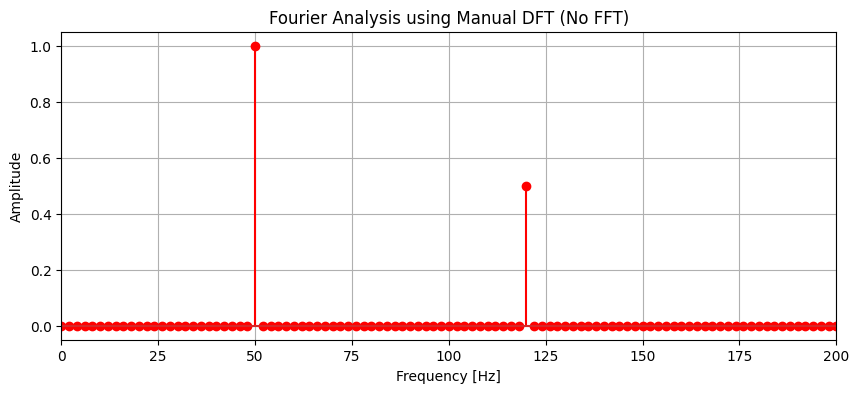

In [7]:
import matplotlib.pyplot as plt
import numpy as np


# --- 【ここがポイント】定義通りの離散フーリエ変換 (DFT) ---
def dft_sequence(signal):
    N = len(signal)
    # 空の配列を用意（複素数型 complex）
    X = np.zeros(N, dtype=complex)

    # 定義式通りの2重ループ計算
    for k in range(N):
        sum_val = 0
        for n in range(N):
            # e^(-j * 2 * pi * k * n / N) の計算
            theta = -2 * np.pi * k * n / N
            W = np.cos(theta) + 1j * np.sin(theta)  # オイラーの公式
            sum_val += signal[n] * W
        X[k] = sum_val
    return X


# 1. サンプリング設定（計算量削減のためデータ数を少し減らしています）
fs = 500  # サンプリング周波数 (Hz)
t = np.arange(0, 0.5, 1 / fs)  # 0.5秒分のデータ

# 2. 三角関数の組み合わせ（50Hz と 120Hz）
f1, a1 = 50, 1.0
f2, a2 = 120, 0.5
signal = a1 * np.sin(2 * np.pi * f1 * t) + a2 * np.sin(2 * np.pi * f2 * t)

# 3. 自作のフーリエ変換を実行
N = len(t)
dft_vals = dft_sequence(signal)  # ← ここで自作関数を呼び出し
dft_freq = np.fft.fftfreq(N, 1 / fs)  # 周波数軸の作成は便利なのでライブラリを使用

# 正の周波数成分と振幅の正規化
positive_frequencies = dft_freq[: N // 2]
amplitude_spectrum = np.abs(dft_vals[: N // 2]) * 2 / N

# 4. 作図
plt.figure(figsize=(10, 4))
plt.stem(
    positive_frequencies, amplitude_spectrum, linefmt="red"
)
plt.title("Fourier Analysis using Manual DFT (No FFT)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(0, 200)
plt.grid(True)
plt.show()